In [36]:
import sys
sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")

import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from PIL import Image

# Load autoreload for development
%load_ext autoreload
%autoreload 2    

In [ ]:
# Load model from saved .pth file
def load_model_from_pth(pth_path, device="cuda"):
    """Load model from saved .pth bundle"""
    print(f"Loading model from: {pth_path}")
    
    # Load the saved bundle
    bundle = torch.load(pth_path, map_location="cpu")
    print(f"Bundle keys: {list(bundle.keys())}")
    
    # Reconstruct model from saved components
    from models import RGBDistillDecomposer, DINOv3, DPT_Decoder
    from dotmap import DotMap
    
    # Reconstruct DINOv3
    if "dinov3_config" in bundle:
        dinov3_config = bundle["dinov3_config"]
        if isinstance(dinov3_config, dict):
            dinov3_config = DotMap(dinov3_config)
        dinov3 = DINOv3(dinov3_config)
        print("✓ Reconstructed DINOv3")
    else:
        print("⚠ No DINOv3 config found, creating minimal DINOv3")
        dinov3 = DINOv3({})
    
    # Reconstruct decoders
    decoders = {}
    if "decoders_config" in bundle:
        for name, decoder_config in bundle["decoders_config"].items():
            if decoder_config is not None:
                if isinstance(decoder_config, dict):
                    decoder_config = DotMap(decoder_config)
                decoders[name] = DPT_Decoder(decoder_config)
            else:
                decoders[name] = DPT_Decoder({})
        print(f"✓ Reconstructed {len(decoders)} decoders: {list(decoders.keys())}")
    
    # Create model
    model = RGBDistillDecomposer(
        dinov3=dinov3,
        decoders=decoders,
        patch_size=bundle.get("patch_size", 16)
    )
    
    # Load state dict
    model.load_state_dict(bundle["state_dict"], strict=False)
    model = model.to(device).eval()
    
    print(f"✓ Model loaded successfully on {device}")
    return model

# Load the model
model = load_model_from_pth("noscared.pth", device="cuda")


INFO     [17:53:05] Found valid run to resume: 
/anvme/workspace/v120bb18-unreflectanything/results/copper-plasma-112

INFO     [17:53:05] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/copper-plasma-112/models/weights_best.pt

INFO     [17:53:05] Latest epoch: 10

IMPORT   [17:53:08] Torch Compile time: 2.36 seconds

MODEL    [17:53:08] Model with class OptimizedModule created with 111,351,812 parameters

In [37]:
# Test model on a sample image
def test_model_on_image(model, image_path=None, device="cuda"):
    """Test the model on an image and print tensor shapes"""
    
    # Create a dummy RGB image if no path provided
    if image_path is None:
        print("Creating dummy RGB image for testing...")
        # Create a random RGB image: [B, 3, H, W] in [0, 1] range
        dummy_image = torch.rand(1, 3, 896, 896, device=device)
        print(f"Input image shape: {dummy_image.shape}")
    else:
        # Load and preprocess real image
        print(f"Loading image from: {image_path}")
        image = Image.open(image_path).convert('RGB')
        
        # Resize to model's expected input size
        transform = transforms.Compose([
            transforms.Resize((896, 896)),
            transforms.ToTensor()
        ])
        dummy_image = transform(image).unsqueeze(0).to(device)  # Add batch dimension
        print(f"Input image shape: {dummy_image.shape}")
    
    # Prepare input dictionary
    input_data = {"rgb": dummy_image}
    
    # Run inference
    print("\nRunning inference...")
    with torch.no_grad():
        outputs = model(input_data)
    
    # Print output shapes
    print("\n" + "="*50)
    print("MODEL OUTPUT SHAPES:")
    print("="*50)
    for key, output in outputs.items():
        print(f"{key}: {output.shape}")
    
    # Print input shape for reference
    print(f"\nInput RGB: {input_data['rgb'].shape}")
    
    return outputs, input_data

# Test the model
outputs, input_data = test_model_on_image(model)


Creating dummy RGB image for testing...
Input image shape: torch.Size([1, 3, 896, 896])

Running inference...

MODEL OUTPUT SHAPES:
diffuse: torch.Size([1, 3, 896, 896])
highlight: torch.Size([1, 1, 896, 896])

Input RGB: torch.Size([1, 3, 896, 896])


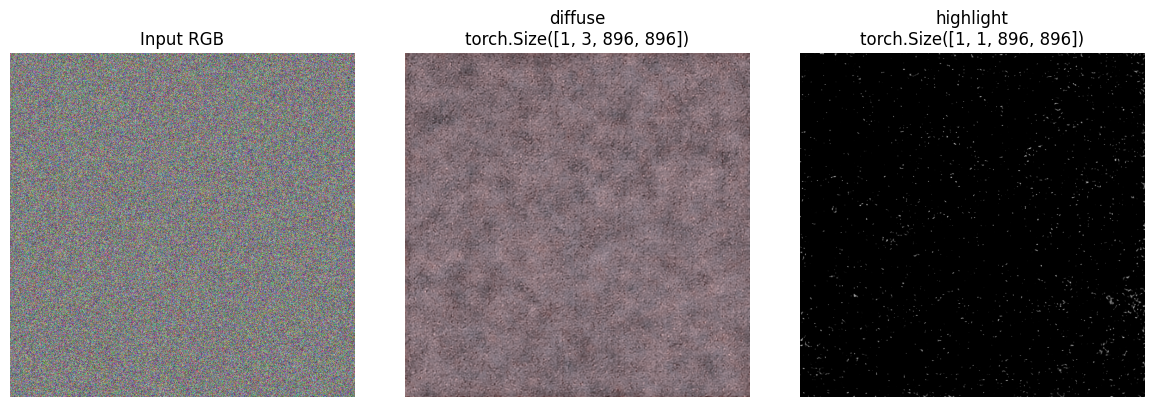

In [38]:
# Visualize model outputs using matplotlib
def visualize_outputs(input_data, outputs, save_path=None):
    """Visualize input and model outputs using matplotlib"""
    
    # Convert tensors to numpy for visualization
    input_rgb = input_data["rgb"][0].cpu().numpy()  # Remove batch dimension
    input_rgb = np.transpose(input_rgb, (1, 2, 0))  # [H, W, C]
    
    # Create subplot grid
    n_outputs = len(outputs)
    fig, axes = plt.subplots(1, n_outputs + 1, figsize=(4 * (n_outputs + 1), 4))
    
    # Plot input image
    axes[0].imshow(input_rgb)
    axes[0].set_title("Input RGB")
    axes[0].axis('off')
    
    # Plot each output
    for i, (key, output) in enumerate(outputs.items(), 1):
        output_np = output[0].cpu().numpy()  # Remove batch dimension
        
        if output_np.shape[0] == 3:  # RGB output
            output_np = np.transpose(output_np, (1, 2, 0))  # [H, W, C]
            axes[i].imshow(output_np)
        else:  # Single channel output
            output_np = output_np[0]  # Remove channel dimension
            axes[i].imshow(output_np, cmap='gray')
        
        axes[i].set_title(f"{key}\n{output.shape}")
        axes[i].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved to: {save_path}")
    
    plt.show()

# Visualize the results
visualize_outputs(input_data, outputs)


In [ ]:
# Model information and summary
def print_model_info(model):
    """Print model information and parameter count"""
    print("\n" + "="*60)
    print("MODEL INFORMATION")
    print("="*60)
    print(f"Model type: {type(model).__name__}")
    print(f"Device: {next(model.parameters()).device}")
    print(f"Training mode: {model.training}")
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\nParameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,}")
    print(f"  Frozen: {total_params - trainable_params:,}")
    print(f"  Trainable ratio: {trainable_params/total_params*100:.1f}%")
    
    # Model size estimate
    size_mb = total_params * 4 / (1024 * 1024)  # Assuming float32
    print(f"  Estimated size: {size_mb:.1f} MB")
    
    print("="*60)

print_model_info(model)

In [ ]:
# Additional testing: Test with different input sizes
def test_different_sizes(model, device="cuda"):
    """Test model with different input sizes"""
    print("\n" + "="*50)
    print("TESTING DIFFERENT INPUT SIZES")
    print("="*50)
    
    sizes = [(224, 224), (448, 448), (896, 896)]
    
    for h, w in sizes:
        print(f"\nTesting size: {h}x{w}")
        try:
            # Create dummy input
            dummy_input = torch.rand(1, 3, h, w, device=device)
            input_data = {"rgb": dummy_input}
            
            # Run inference
            with torch.no_grad():
                outputs = model(input_data)
            
            print(f"  Input: {dummy_input.shape}")
            for key, output in outputs.items():
                print(f"  {key}: {output.shape}")
                
        except Exception as e:
            print(f"  Error: {e}")

# Uncomment to test different sizes
# test_different_sizes(model)

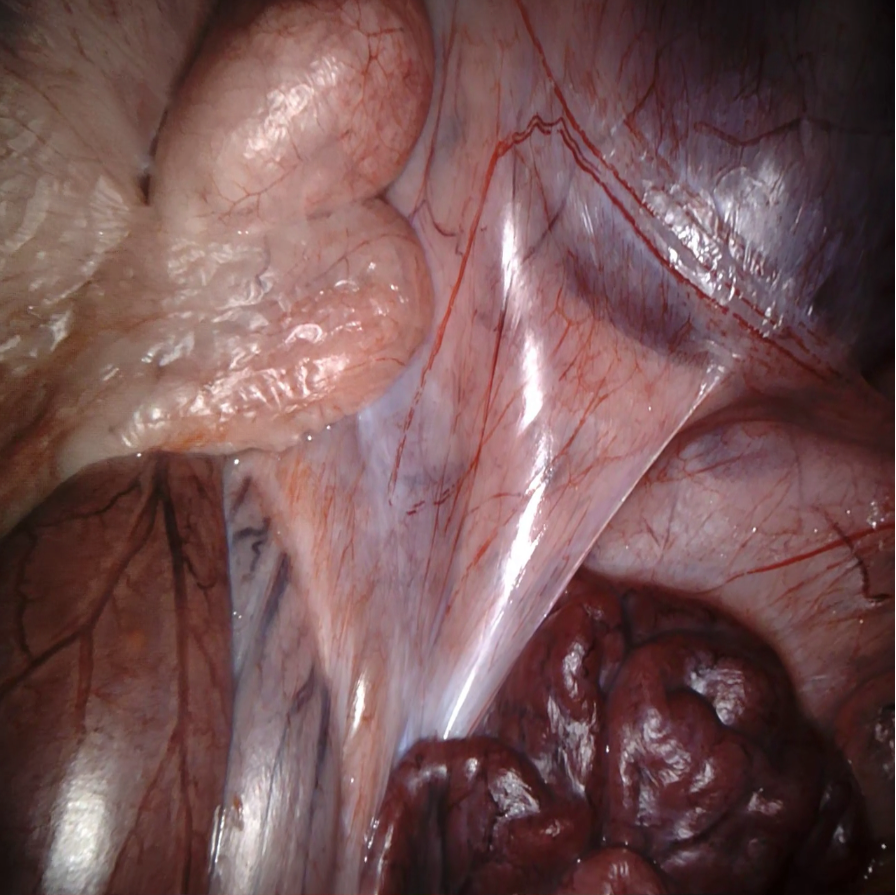

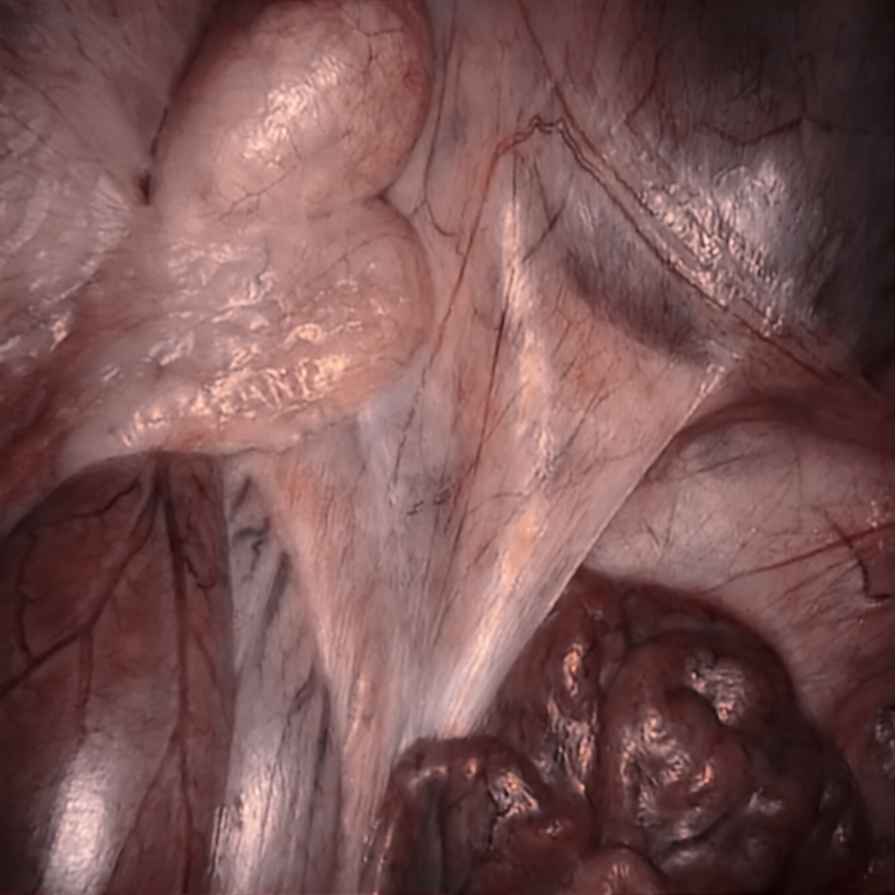

In [ ]:
# Summary and next steps
print("\n" + "="*60)
print("NOTEBOOK SUMMARY")
print("="*60)
print("✓ Model loaded from .pth file")
print("✓ Model tested on dummy image")
print("✓ Tensor shapes printed")
print("✓ Visualizations created with matplotlib")
print("✓ Minimal dependencies used")
print("\nNext steps:")
print("- Test with real images by uncommenting the test_different_sizes() call")
print("- Modify image paths in test_model_on_image() to use your own images")
print("- Adjust visualization parameters as needed")
print("="*60)